# 68 — K-means Clustering in 3D (ISCX + USBVPN + VNAT)

**Goal.** Run unsupervised K-means on the merged three-dataset corpus and
inspect the geometry in a 3-D PCA projection, against two reference labellings:

1. **Dataset identity** — does K-means recover the three corpora (ISCX, USBVPN, VNAT)?
2. **VPN vs non-VPN class** — does K-means recover the binary traffic class?

**Data source.** Cached canonical raw-feature table produced by the sign-reversal
forensic audit pipeline:

```
artifacts/sign_reversal_forensic_audit/intermediate/canonical_safe_core_plus_temporal_300.parquet
```

It contains the 21 raw `safe_core_plus_temporal` features per flow, with
`dataset` and `label` (1 = VPN, 0 = non-VPN), for every flow that satisfies
`min_packets = 3`.

**Method.**
* StandardScaler on the 21 raw features (K-means is scale-sensitive).
* PCA → 3 components for visualisation; K-means is **fit on the same 3-D PCA
  space** so that the cluster boundaries shown in the figures exactly match
  the assignments reported in the cross-tabulations.
* Cluster-vs-label agreement: cross-tab, Adjusted Rand Index (ARI),
  Normalised Mutual Information (NMI), and best-permutation purity.

All figures and tables are written under
`artifacts/kmeans_3d_clustering/`.

## 1. Setup

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3-D projection)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

CANONICAL_PARQUET = (
    REPO_ROOT
    / 'artifacts'
    / 'sign_reversal_forensic_audit'
    / 'intermediate'
    / 'canonical_safe_core_plus_temporal_300.parquet'
)
OUT_DIR = REPO_ROOT / 'artifacts' / 'kmeans_3d_clustering'
FIG_DIR = OUT_DIR / 'figures'
TBL_DIR = OUT_DIR / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

print('Repo root :', REPO_ROOT)
print('Canonical :', CANONICAL_PARQUET.relative_to(REPO_ROOT))
print('Output dir:', OUT_DIR.relative_to(REPO_ROOT))

Repo root : C:\Users\scoti\PycharmProjects\ai-vpn-firewall
Canonical : artifacts\sign_reversal_forensic_audit\intermediate\canonical_safe_core_plus_temporal_300.parquet
Output dir: artifacts\kmeans_3d_clustering


## 2. Load canonical raw-feature table

In [2]:
assert CANONICAL_PARQUET.exists(), (
    f'Canonical parquet not found at {CANONICAL_PARQUET}. '
    'Run `python -m src.eval.sign_reversal_forensic_audit` first.'
)

df = pd.read_parquet(CANONICAL_PARQUET)
print('Rows:', len(df), '| Cols:', df.shape[1])

META_COLS = {
    'flow_id', 'capture_id', 'dataset', 'label', 'source_file', 'app',
    'vpn_protocol', 'raw_label_source', 'raw_label_value',
    'raw_packet_count_full', 'window_packets_used', 'was_truncated',
    'raw_flow_duration_full',
}
FEATURES = [c for c in df.columns if c not in META_COLS]
print(f'Using {len(FEATURES)} raw features:')
print(FEATURES)

print()
print('Counts by (dataset, label):')
display(
    df.groupby(['dataset', 'label']).size().rename('n').reset_index()
      .pivot(index='dataset', columns='label', values='n')
      .rename(columns={0: 'non_vpn', 1: 'vpn'})
      .fillna(0).astype(int)
)

Rows: 72612 | Cols: 34
Using 21 raw features:
['total_packets', 'total_bytes', 'mean_pkt_len', 'std_pkt_len', 'median_pkt_len', 'p25_pkt_len', 'p75_pkt_len', 'iat_mean', 'iat_std', 'iat_median', 'flow_duration', 'packet_rate', 'byte_rate', 'max_pkt_len', 'min_pkt_len', 'iat_cv', 'iat_p25', 'iat_p75', 'iat_iqr', 'pkt_len_cv', 'pkt_len_iqr']

Counts by (dataset, label):


label,non_vpn,vpn
dataset,,
iscx,8858,2943
usbvpn,44248,8456
vnat,7733,374


## 3. Preprocess: StandardScaler + PCA → 3D

* Drop rows with any non-finite raw-feature value (a tiny minority).
* StandardScale the 21 features.
* PCA to 3 components — this is the space K-means will be fit and
  visualised in, so cluster colours and 3-D positions are consistent.

In [3]:
X_raw = df[FEATURES].to_numpy(dtype=np.float64)
finite_mask = np.all(np.isfinite(X_raw), axis=1)
if (~finite_mask).any():
    dropped = int((~finite_mask).sum())
    print(f'Dropping {dropped} rows with non-finite raw features '
          f'({dropped / len(df) * 100:.3f}%).')
df = df.loc[finite_mask].reset_index(drop=True)
X_raw = X_raw[finite_mask]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_3d = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
print(f'PCA variance explained by 3 components: '
      f'PC1={evr[0]:.3f}, PC2={evr[1]:.3f}, PC3={evr[2]:.3f}, '
      f'sum={evr.sum():.3f}')

df['pc1'] = X_3d[:, 0]
df['pc2'] = X_3d[:, 1]
df['pc3'] = X_3d[:, 2]

PCA variance explained by 3 components: PC1=0.328, PC2=0.231, PC3=0.131, sum=0.690


## 4. Helpers

* `cluster_vs_label_summary` — cross-tab, ARI, NMI, best-permutation purity.
* `stratified_subsample` — keep 3-D scatter readable (~6 k points)
  while preserving class proportions; K-means is fit on the **full** set.
* `plot_3d` — uniform styling for the four 3-D scatter figures.

In [4]:
def _best_permutation_accuracy(true: np.ndarray, pred: np.ndarray) -> float:
    '''Hungarian-assignment accuracy (a.k.a. cluster purity under best label permutation).'''
    true = np.asarray(true)
    pred = np.asarray(pred)
    true_labels = np.unique(true)
    pred_labels = np.unique(pred)
    cost = np.zeros((len(pred_labels), len(true_labels)), dtype=np.int64)
    for i, p in enumerate(pred_labels):
        for j, t in enumerate(true_labels):
            cost[i, j] = -int(((pred == p) & (true == t)).sum())
    row_ind, col_ind = linear_sum_assignment(cost)
    correct = -cost[row_ind, col_ind].sum()
    return float(correct) / float(len(true))

def cluster_vs_label_summary(
    *,
    true: np.ndarray,
    pred: np.ndarray,
    true_name: str,
    pred_name: str = 'kmeans_cluster',
) -> dict:
    ct = pd.crosstab(
        pd.Series(pred, name=pred_name),
        pd.Series(true, name=true_name),
    )
    ari = float(adjusted_rand_score(true, pred))
    nmi = float(normalized_mutual_info_score(true, pred))
    purity = _best_permutation_accuracy(true, pred)
    return {'crosstab': ct, 'ari': ari, 'nmi': nmi, 'purity': purity}

def stratified_subsample(
    df_in: pd.DataFrame,
    *,
    strata_cols: list[str],
    max_total: int = 6000,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    groups = df_in.groupby(strata_cols, observed=True)
    sizes = groups.size()
    total = int(sizes.sum())
    if total <= max_total:
        return df_in
    frac = max_total / total
    parts = []
    for key, idx in groups.groups.items():
        n_take = max(1, int(round(len(idx) * frac)))
        n_take = min(n_take, len(idx))
        parts.append(df_in.loc[idx].sample(n=n_take, random_state=random_state))
    return pd.concat(parts).sort_index()

def plot_3d(
    df_in: pd.DataFrame,
    *,
    color_col: str,
    title: str,
    save_path: Path,
    palette: dict | None = None,
    cmap_fallback: str = 'tab10',
    point_size: float = 6.0,
    alpha: float = 0.55,
) -> None:
    fig = plt.figure(figsize=(8.5, 7.0))
    ax = fig.add_subplot(111, projection='3d')
    categories = sorted(df_in[color_col].unique().tolist(),
                        key=lambda v: str(v))
    if palette is None:
        base = plt.get_cmap(cmap_fallback).colors
        palette = {c: base[i % len(base)] for i, c in enumerate(categories)}
    for cat in categories:
        sub = df_in[df_in[color_col] == cat]
        ax.scatter(
            sub['pc1'], sub['pc2'], sub['pc3'],
            s=point_size, alpha=alpha,
            color=palette[cat],
            label=str(cat),
            edgecolors='none',
        )
    ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
    ax.set_zlabel(f'PC3 ({evr[2]*100:.1f}%)')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=9, framealpha=0.85, markerscale=2.0)
    ax.view_init(elev=20, azim=-60)
    fig.tight_layout()
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path.relative_to(REPO_ROOT))

## 5. Part A — K-means (k = 3) vs dataset identity

Fit K-means with `k = 3` on the 3-D PCA projection of all three datasets
and compare the resulting clusters to the true `dataset` label.

In [5]:
K_A = 3
kmeans_dataset = KMeans(
    n_clusters=K_A,
    n_init=20,
    random_state=RANDOM_STATE,
).fit(X_3d)
df['cluster_k3'] = kmeans_dataset.labels_

summary_dataset = cluster_vs_label_summary(
    true=df['dataset'].to_numpy(),
    pred=df['cluster_k3'].to_numpy(),
    true_name='dataset',
)
print('K-means (k=3) vs dataset')
print(f'  ARI    = {summary_dataset["ari"]:.4f}')
print(f'  NMI    = {summary_dataset["nmi"]:.4f}')
print(f'  Purity = {summary_dataset["purity"]:.4f}  (best-permutation accuracy)')
try:
    sil_k3 = float(silhouette_score(X_3d, kmeans_dataset.labels_, sample_size=10000,
                                    random_state=RANDOM_STATE))
    print(f'  Silhouette (3-D, sample) = {sil_k3:.4f}')
except Exception as exc:
    sil_k3 = float('nan')
    print('  Silhouette: not computed ({})'.format(exc))
print()
print('Cross-tab (rows = K-means cluster, cols = dataset):')
display(summary_dataset['crosstab'])

ct_path = TBL_DIR / 'kmeans_k3_vs_dataset_crosstab.csv'
summary_dataset['crosstab'].to_csv(ct_path)
print('Saved:', ct_path.relative_to(REPO_ROOT))

K-means (k=3) vs dataset
  ARI    = -0.0652
  NMI    = 0.0925
  Purity = 0.5347  (best-permutation accuracy)
  Silhouette (3-D, sample) = 0.5889

Cross-tab (rows = K-means cluster, cols = dataset):


dataset,iscx,usbvpn,vnat
kmeans_cluster,,,
0,479,15180,563
1,11322,37524,6720
2,0,0,824


Saved: artifacts\kmeans_3d_clustering\tables\kmeans_k3_vs_dataset_crosstab.csv


Plotting 6000 of 72612 points (stratified).


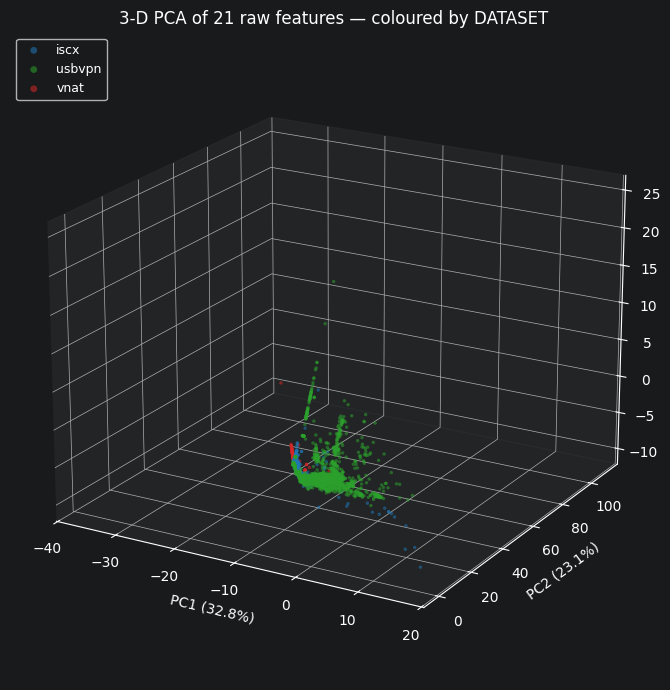

Saved: artifacts\kmeans_3d_clustering\figures\pca3d_by_dataset.png


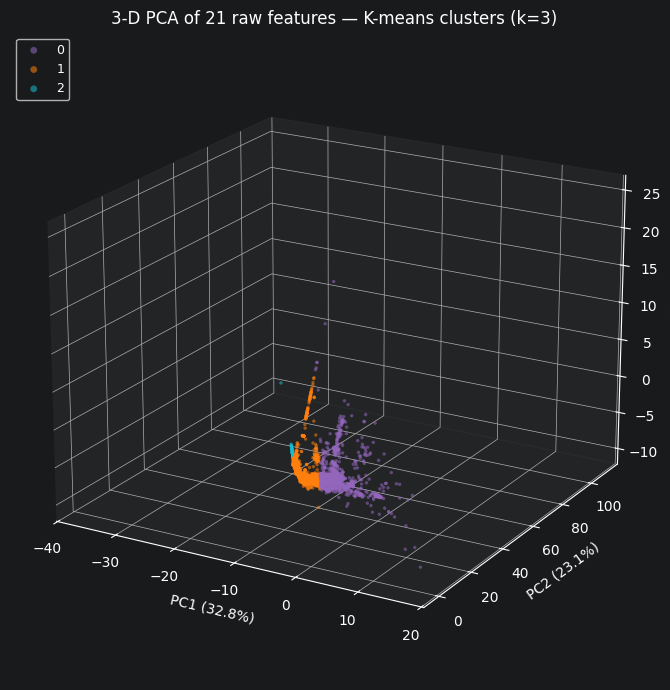

Saved: artifacts\kmeans_3d_clustering\figures\pca3d_kmeans_k3_clusters.png


In [6]:
# Subsample for readable 3-D scatter (stratified by dataset + label).
df_plot_A = stratified_subsample(
    df, strata_cols=['dataset', 'label'], max_total=6000,
)
print(f'Plotting {len(df_plot_A)} of {len(df)} points (stratified).')

DATASET_COLORS = {'iscx': '#1f77b4', 'usbvpn': '#2ca02c', 'vnat': '#d62728'}
CLUSTER_COLORS = {0: '#9467bd', 1: '#ff7f0e', 2: '#17becf'}

plot_3d(
    df_plot_A,
    color_col='dataset',
    title='3-D PCA of 21 raw features — coloured by DATASET',
    save_path=FIG_DIR / 'pca3d_by_dataset.png',
    palette=DATASET_COLORS,
)

plot_3d(
    df_plot_A,
    color_col='cluster_k3',
    title=f'3-D PCA of 21 raw features — K-means clusters (k={K_A})',
    save_path=FIG_DIR / 'pca3d_kmeans_k3_clusters.png',
    palette=CLUSTER_COLORS,
)

## 6. Part B — K-means (k = 2) vs VPN / non-VPN class

Fit K-means with `k = 2` on the same 3-D PCA projection (all three datasets
merged) and compare clusters to the binary `label` (1 = VPN, 0 = non-VPN).

In [7]:
K_B = 2
kmeans_vpn = KMeans(
    n_clusters=K_B,
    n_init=20,
    random_state=RANDOM_STATE,
).fit(X_3d)
df['cluster_k2'] = kmeans_vpn.labels_

summary_vpn = cluster_vs_label_summary(
    true=df['label'].to_numpy(),
    pred=df['cluster_k2'].to_numpy(),
    true_name='label',
)
print('K-means (k=2) vs VPN/non-VPN (all 3 datasets merged)')
print(f'  ARI    = {summary_vpn["ari"]:.4f}')
print(f'  NMI    = {summary_vpn["nmi"]:.4f}')
print(f'  Purity = {summary_vpn["purity"]:.4f}  (best-permutation accuracy)')
try:
    sil_k2 = float(silhouette_score(X_3d, kmeans_vpn.labels_, sample_size=10000,
                                    random_state=RANDOM_STATE))
    print(f'  Silhouette (3-D, sample) = {sil_k2:.4f}')
except Exception as exc:
    sil_k2 = float('nan')
    print('  Silhouette: not computed ({})'.format(exc))
print()
print('Cross-tab (rows = K-means cluster, cols = label):')
display(summary_vpn['crosstab'])

ct_path_b = TBL_DIR / 'kmeans_k2_vs_vpn_crosstab.csv'
summary_vpn['crosstab'].to_csv(ct_path_b)
print('Saved:', ct_path_b.relative_to(REPO_ROOT))

K-means (k=2) vs VPN/non-VPN (all 3 datasets merged)
  ARI    = 0.2574
  NMI    = 0.1200
  Purity = 0.8003  (best-permutation accuracy)
  Silhouette (3-D, sample) = 0.5625

Cross-tab (rows = K-means cluster, cols = label):


label,0,1
kmeans_cluster,,
0,51336,5001
1,9503,6772


Saved: artifacts\kmeans_3d_clustering\tables\kmeans_k2_vs_vpn_crosstab.csv


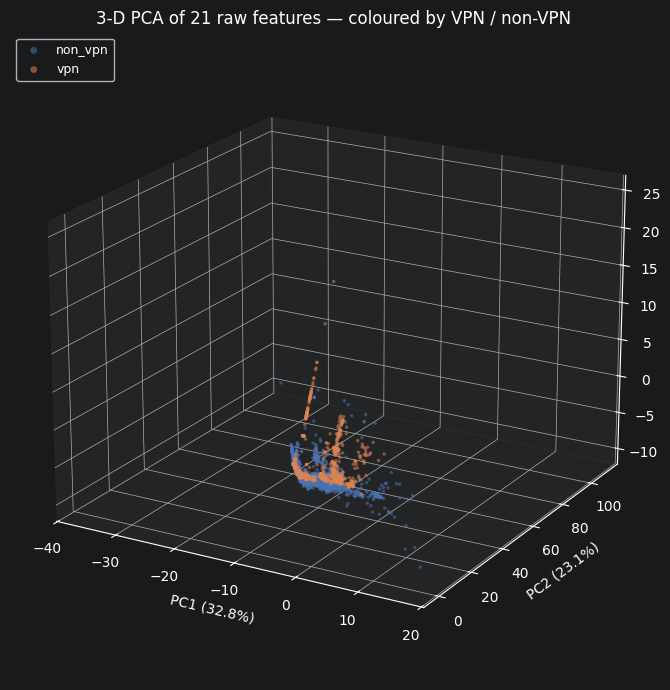

Saved: artifacts\kmeans_3d_clustering\figures\pca3d_by_vpn_label.png


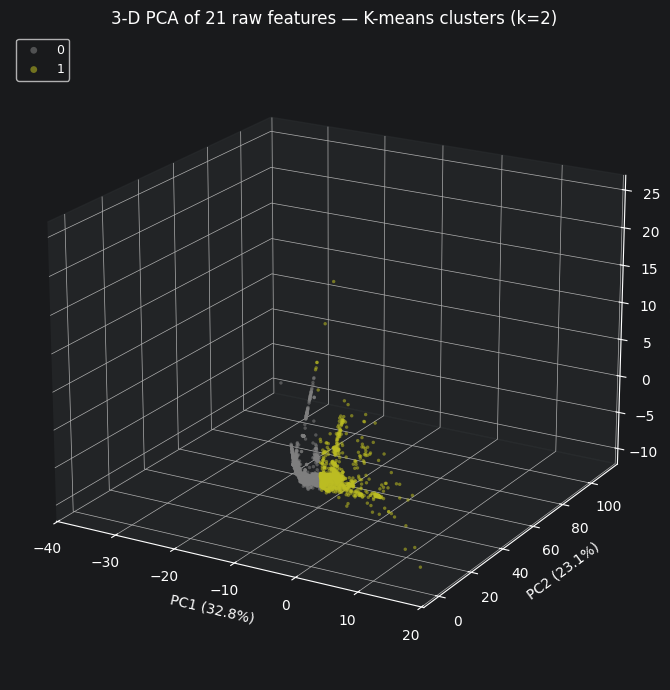

Saved: artifacts\kmeans_3d_clustering\figures\pca3d_kmeans_k2_clusters.png


In [8]:
df_plot_B = stratified_subsample(
    df, strata_cols=['dataset', 'label'], max_total=6000,
)

VPN_COLORS = {0: '#4c72b0', 1: '#dd8452'}
VPN_LABELS = {0: 'non_vpn', 1: 'vpn'}
df_plot_B = df_plot_B.assign(label_name=df_plot_B['label'].map(VPN_LABELS))

plot_3d(
    df_plot_B,
    color_col='label_name',
    title='3-D PCA of 21 raw features — coloured by VPN / non-VPN',
    save_path=FIG_DIR / 'pca3d_by_vpn_label.png',
    palette={'non_vpn': VPN_COLORS[0], 'vpn': VPN_COLORS[1]},
)

plot_3d(
    df_plot_B,
    color_col='cluster_k2',
    title=f'3-D PCA of 21 raw features — K-means clusters (k={K_B})',
    save_path=FIG_DIR / 'pca3d_kmeans_k2_clusters.png',
    palette={0: '#7f7f7f', 1: '#bcbd22'},
)

## 7. Per-dataset K-means (k = 2) vs VPN / non-VPN

For completeness, run K-means with `k = 2` **within each dataset** and
report how well the unsupervised clustering recovers VPN vs non-VPN in
that single corpus. This isolates whether the merged-corpus geometry is
dominated by dataset identity or by class.

In [9]:
per_ds_rows = []
for ds_name in sorted(df['dataset'].unique()):
    sub = df[df['dataset'] == ds_name]
    if sub['label'].nunique() < 2:
        continue
    km = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
    km.fit(sub[['pc1', 'pc2', 'pc3']].to_numpy())
    s = cluster_vs_label_summary(
        true=sub['label'].to_numpy(),
        pred=km.labels_,
        true_name='label',
    )
    per_ds_rows.append({
        'dataset': ds_name,
        'n_flows': int(len(sub)),
        'n_vpn': int((sub['label'] == 1).sum()),
        'n_nonvpn': int((sub['label'] == 0).sum()),
        'ari_kmeans_vs_vpn': s['ari'],
        'nmi_kmeans_vs_vpn': s['nmi'],
        'purity_kmeans_vs_vpn': s['purity'],
    })

per_ds = pd.DataFrame(per_ds_rows)
display(per_ds)
per_ds_path = TBL_DIR / 'kmeans_k2_vs_vpn_per_dataset.csv'
per_ds.to_csv(per_ds_path, index=False)
print('Saved:', per_ds_path.relative_to(REPO_ROOT))

,dataset,n_flows,n_vpn,n_nonvpn,ari_kmeans_vs_vpn,nmi_kmeans_vs_vpn,purity_kmeans_vs_vpn
0,iscx,11801,2943,8858,-0.018169,0.013153,0.736124
1,usbvpn,52704,8456,44248,0.302470,0.164893,0.810527
2,vnat,8107,374,7733,-0.055867,0.019301,0.855187


Saved: artifacts\kmeans_3d_clustering\tables\kmeans_k2_vs_vpn_per_dataset.csv


## 8. Interactive rotatable 3-D scatter plots (Plotly)

The static matplotlib PNGs above are great for reports, but they are
frozen at one viewing angle. The cells below render the **same four**
3-D scatter plots with [Plotly](https://plotly.com/python/3d-scatter-plots/),
which gives:

* **Drag-to-rotate** orbit / turntable / pan controls.
* **Scroll-zoom** and box-select.
* **Hover tooltips** showing dataset, label, capture, cluster id, and the 3 PCA coords.
* **Legend click** to hide/isolate any class or cluster.

Each figure is also written to disk as a **standalone, self-contained HTML
file** (`include_plotlyjs='cdn'`, ~few KB each) under
`artifacts/kmeans_3d_clustering/figures/interactive/`. Open those HTML
files in any browser — no kernel, no Jupyter, no internet required apart from
the one-time CDN load of plotly.js — and rotate the plots freely.

If the inline plot is not interactive in your editor:

* In **JupyterLab / Notebook 7**: install `jupyterlab` ≥ 3 (plotly renders natively).
* In **PyCharm Pro Jupyter view**: it may show as a static snapshot — in that case
  open the saved HTML file directly (double-click in the project tree).
* In **VS Code**: works out of the box.

In [10]:
import plotly.graph_objects as go
import plotly.io as pio

INTERACTIVE_DIR = FIG_DIR / 'interactive'
INTERACTIVE_DIR.mkdir(parents=True, exist_ok=True)

# Use a notebook-friendly default renderer when available.
try:
    pio.renderers.default = 'notebook_connected'
except Exception:
    pio.renderers.default = 'browser'

AXIS_LABELS = {
    'x': f'PC1 ({evr[0]*100:.1f}%)',
    'y': f'PC2 ({evr[1]*100:.1f}%)',
    'z': f'PC3 ({evr[2]*100:.1f}%)',
}

# Same stratified subsample as the static figures so the visuals match.
df_plot_I = stratified_subsample(
    df, strata_cols=['dataset', 'label'], max_total=6000,
)
df_plot_I = df_plot_I.assign(
    label_name=df_plot_I['label'].map({0: 'non_vpn', 1: 'vpn'}),
    cluster_k3_name=df_plot_I['cluster_k3'].map(lambda c: f'cluster_{int(c)}'),
    cluster_k2_name=df_plot_I['cluster_k2'].map(lambda c: f'cluster_{int(c)}'),
)
print(f'Plotting {len(df_plot_I)} points interactively.')

def plot_3d_interactive(
    df_in: pd.DataFrame,
    *,
    color_col: str,
    title: str,
    palette: dict,
    save_html: Path,
    point_size: int = 3,
    opacity: float = 0.7,
) -> go.Figure:
    fig = go.Figure()
    categories = sorted(df_in[color_col].unique().tolist(), key=lambda v: str(v))
    for cat in categories:
        sub = df_in[df_in[color_col] == cat]
        hover = (
            'flow_id=' + sub['flow_id'].astype(str)
            + '<br>dataset=' + sub['dataset'].astype(str)
            + '<br>label=' + sub['label'].astype(str)
            + '<br>cluster_k3=' + sub['cluster_k3'].astype(str)
            + '<br>cluster_k2=' + sub['cluster_k2'].astype(str)
            + '<br>capture_id=' + sub['capture_id'].astype(str)
        )
        fig.add_trace(go.Scatter3d(
            x=sub['pc1'], y=sub['pc2'], z=sub['pc3'],
            mode='markers',
            name=str(cat),
            marker=dict(size=point_size, color=palette[cat], opacity=opacity,
                        line=dict(width=0)),
            text=hover,
            hovertemplate='%{text}<br>PC1=%{x:.2f}<br>PC2=%{y:.2f}<br>PC3=%{z:.2f}<extra></extra>',
        ))
    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor='center'),
        scene=dict(
            xaxis_title=AXIS_LABELS['x'],
            yaxis_title=AXIS_LABELS['y'],
            zaxis_title=AXIS_LABELS['z'],
            camera=dict(eye=dict(x=1.6, y=1.6, z=1.1)),
        ),
        legend=dict(itemsizing='constant'),
        width=900, height=720,
        margin=dict(l=0, r=0, t=50, b=0),
        template='plotly_white',
    )
    fig.write_html(save_html, include_plotlyjs='cdn', full_html=True)
    print('Saved:', save_html.relative_to(REPO_ROOT))
    return fig

Plotting 6000 points interactively.


### 8.1 Interactive — coloured by **dataset** (ISCX / USBVPN / VNAT)

Drag to rotate. Click legend entries to isolate a single dataset.

In [11]:
fig_dataset = plot_3d_interactive(
    df_plot_I,
    color_col='dataset',
    title='3-D PCA of 21 raw features — coloured by DATASET (interactive)',
    palette=DATASET_COLORS,
    save_html=INTERACTIVE_DIR / 'pca3d_by_dataset.html',
)
fig_dataset.show()

Saved: artifacts\kmeans_3d_clustering\figures\interactive\pca3d_by_dataset.html


### 8.2 Interactive — K-means clusters (k = 3)

In [12]:
fig_k3 = plot_3d_interactive(
    df_plot_I,
    color_col='cluster_k3_name',
    title='3-D PCA of 21 raw features — K-means clusters (k=3, interactive)',
    palette={f'cluster_{c}': CLUSTER_COLORS[c] for c in CLUSTER_COLORS},
    save_html=INTERACTIVE_DIR / 'pca3d_kmeans_k3_clusters.html',
)
fig_k3.show()

Saved: artifacts\kmeans_3d_clustering\figures\interactive\pca3d_kmeans_k3_clusters.html


### 8.3 Interactive — coloured by **VPN / non-VPN**

In [13]:
fig_vpn = plot_3d_interactive(
    df_plot_I,
    color_col='label_name',
    title='3-D PCA of 21 raw features — coloured by VPN / non-VPN (interactive)',
    palette={'non_vpn': VPN_COLORS[0], 'vpn': VPN_COLORS[1]},
    save_html=INTERACTIVE_DIR / 'pca3d_by_vpn_label.html',
)
fig_vpn.show()

Saved: artifacts\kmeans_3d_clustering\figures\interactive\pca3d_by_vpn_label.html


### 8.4 Interactive — K-means clusters (k = 2)

In [16]:
fig_k2 = plot_3d_interactive(
    df_plot_I,
    color_col='cluster_k2_name',
    title='3-D PCA of 21 raw features — K-means clusters (k=3, interactive)',
    palette={'cluster_0': '#7f7f7f', 'cluster_1': '#bcbd22'},
    save_html=INTERACTIVE_DIR / 'pca3d_kmeans_k2_clusters.html',
)
fig_k2.show()

Saved: artifacts\kmeans_3d_clustering\figures\interactive\pca3d_kmeans_k2_clusters.html


### 8.5 (Optional) Matplotlib widget backend

If you would rather keep matplotlib but make those 3-D scatters rotatable,
install [`ipympl`](https://github.com/matplotlib/ipympl) (`pip install ipympl`),
restart the kernel, and prepend a cell with:

```python
%matplotlib widget
```

Then re-run section 5 / 6 — the matplotlib `Axes3D` figures become
interactive (drag to rotate, scroll to zoom). PyCharm Pro's Jupyter view
supports this; if the widget does not appear, fall back to the plotly HTML
files produced above.

## 9. Final summary

Persist a JSON manifest with every metric, figure (static + interactive),
and table path so the run is fully traceable.

In [15]:
manifest = {
    'source_parquet': str(CANONICAL_PARQUET.relative_to(REPO_ROOT)),
    'n_flows_total': int(len(df)),
    'features': FEATURES,
    'pca_explained_variance_ratio': [float(v) for v in evr],
    'pca_explained_variance_ratio_sum': float(evr.sum()),
    'kmeans_k3_vs_dataset': {
        'ari': summary_dataset['ari'],
        'nmi': summary_dataset['nmi'],
        'purity_best_permutation': summary_dataset['purity'],
        'silhouette_3d_sample': sil_k3,
        'crosstab_csv': str((TBL_DIR / 'kmeans_k3_vs_dataset_crosstab.csv').relative_to(REPO_ROOT)),
    },
    'kmeans_k2_vs_vpn': {
        'ari': summary_vpn['ari'],
        'nmi': summary_vpn['nmi'],
        'purity_best_permutation': summary_vpn['purity'],
        'silhouette_3d_sample': sil_k2,
        'crosstab_csv': str((TBL_DIR / 'kmeans_k2_vs_vpn_crosstab.csv').relative_to(REPO_ROOT)),
    },
    'kmeans_k2_vs_vpn_per_dataset_csv': str(per_ds_path.relative_to(REPO_ROOT)),
    'figures_static_png': {
        'pca3d_by_dataset': str((FIG_DIR / 'pca3d_by_dataset.png').relative_to(REPO_ROOT)),
        'pca3d_kmeans_k3_clusters': str((FIG_DIR / 'pca3d_kmeans_k3_clusters.png').relative_to(REPO_ROOT)),
        'pca3d_by_vpn_label': str((FIG_DIR / 'pca3d_by_vpn_label.png').relative_to(REPO_ROOT)),
        'pca3d_kmeans_k2_clusters': str((FIG_DIR / 'pca3d_kmeans_k2_clusters.png').relative_to(REPO_ROOT)),
    },
    'figures_interactive_html': {
        'pca3d_by_dataset': str((INTERACTIVE_DIR / 'pca3d_by_dataset.html').relative_to(REPO_ROOT)),
        'pca3d_kmeans_k3_clusters': str((INTERACTIVE_DIR / 'pca3d_kmeans_k3_clusters.html').relative_to(REPO_ROOT)),
        'pca3d_by_vpn_label': str((INTERACTIVE_DIR / 'pca3d_by_vpn_label.html').relative_to(REPO_ROOT)),
        'pca3d_kmeans_k2_clusters': str((INTERACTIVE_DIR / 'pca3d_kmeans_k2_clusters.html').relative_to(REPO_ROOT)),
    },
    'random_state': RANDOM_STATE,
}
manifest_path = OUT_DIR / 'manifest.json'
manifest_path.write_text(json.dumps(manifest, indent=2))
print('Saved:', manifest_path.relative_to(REPO_ROOT))
print(json.dumps(manifest, indent=2))

Saved: artifacts\kmeans_3d_clustering\manifest.json
{
  "source_parquet": "artifacts\\sign_reversal_forensic_audit\\intermediate\\canonical_safe_core_plus_temporal_300.parquet",
  "n_flows_total": 72612,
  "features": [
    "total_packets",
    "total_bytes",
    "mean_pkt_len",
    "std_pkt_len",
    "median_pkt_len",
    "p25_pkt_len",
    "p75_pkt_len",
    "iat_mean",
    "iat_std",
    "iat_median",
    "flow_duration",
    "packet_rate",
    "byte_rate",
    "max_pkt_len",
    "min_pkt_len",
    "iat_cv",
    "iat_p25",
    "iat_p75",
    "iat_iqr",
    "pkt_len_cv",
    "pkt_len_iqr"
  ],
  "pca_explained_variance_ratio": [
    0.32788675773482784,
    0.23067751691365482,
    0.13144516423176286
  ],
  "pca_explained_variance_ratio_sum": 0.6900094388802456,
  "kmeans_k3_vs_dataset": {
    "ari": -0.0652015378881876,
    "nmi": 0.09250930230830384,
    "purity_best_permutation": 0.5347187792651352,
    "silhouette_3d_sample": 0.5889143497248376,
    "crosstab_csv": "artifacts\\k